In [ ]:
import random
import sys
import math  # Added for sin() and radians()

# ==========================================
# 1. HARDCODED SEQUENCES
# ==========================================
KASAMI_SEQ_A = "100100001010011111010101011100000110001010110011001011111101111001101110111001010100101000100101101000110011100111100011011000010001011101011110110111110000110100110101101101010000010011101100100100110000001110100100011100010000000101100011110100001111111"
KASAMI_SEQ_B = "011110111000010000000011001101111100111000111100011101101100000011011100110110000010111001011111011010111100110001110010100010100011010010001000100110001010000110111010111011000001101001011110101011100110011111011110101110011111010011110010001110111101110"

# ==========================================
# 2. CONFIGURATION MODE
# ==========================================
USE_HARDCODED_INPUTS = True  # Set to False to test Phase Inputs

# Defaults if USE_HARDCODED_INPUTS is True
HC_TOTAL_SAMPLES = 4096
HC_END_INDEX_A   = 0   
HC_END_INDEX_B   = 4096   
HC_PHASE_A       = 0      # Degrees
HC_PHASE_B       = 45     # Degrees (Test the strong signal case)
HC_SIGNAL_AMP    = 50     
HC_NOISE_AMP     = 5     

# ==========================================
# 3. CONSTANTS & COLORS
# ==========================================
OVERSAMPLE_FACTOR = 4
SEQ_LENGTH_BITS   = 255
SEQ_LENGTH_SAMPLES = SEQ_LENGTH_BITS * OVERSAMPLE_FACTOR  # 1020 samples

# ANSI Colors
C_RESET  = '\033[0m'
C_NOISE  = '\033[90m' # Gray
C_SEQ_A  = '\033[91m' # Red
C_SEQ_B  = '\033[96m' # Cyan
C_BOTH   = '\033[95m' # Purple (Overlap)
C_GREEN  = '\033[92m'
C_YELLOW = '\033[93m'

def get_valid_int(prompt, min_val, max_val, default=None):
    while True:
        try:
            p_str = f"{prompt} ({min_val}-{max_val})"
            if default is not None:
                p_str += f" [{default}]"
            
            user_input = input(f"{p_str}: ")
            
            if user_input.strip() == "" and default is not None:
                return default
            
            val = int(user_input)
            if min_val <= val <= max_val:
                return val
            print(f"Error: Value must be between {min_val} and {max_val}")
        except ValueError:
            print("Error: Invalid integer.")

def to_hex_8bit(val):
    """Converts int (-128 to 127) to 2-char Hex (2's complement)."""
    # Clip to verify validity before hex conversion
    if val > 127: val = 127
    if val < -128: val = -128
    if val < 0: val = (val + 256) & 0xFF
    return f"{val:02X}"

def inject_sequence_sine(buffer, mask_buf, seq_str, end_idx, amplitude, phase_deg, mask_bit):
    """
    Generates BPSK modulated sine waves with configurable phase shift.
    Phase Shift 0 deg -> Samples at 0, 90, 180, 270 (Ideal Sin: 0, 1, 0, -1)
    Phase Shift 45 deg -> Samples at 45, 135, 225, 315
    """
    if end_idx == 0: return
    
    start_idx = end_idx - SEQ_LENGTH_SAMPLES + 1
    
    # Pre-calculate radians for the phase shift
    phase_rad = math.radians(phase_deg)

    for i, bit in enumerate(seq_str):
        # BPSK Polarity: '1' -> +1, '0' -> -1 (180 deg phase flip)
        polarity = 1 if bit == '1' else -1
        
        for k in range(OVERSAMPLE_FACTOR):
            # Calculate sampling angle: (0, 90, 180, 270) + Phase Shift
            angle_deg = (k * 90)
            angle_rad = math.radians(angle_deg)
            
            # The Formula: Amp * Polarity * sin(theta + phi)
            raw_val = amplitude * polarity * math.sin(angle_rad + phase_rad)
            
            # Accumulate into buffer (integer)
            idx = start_idx + (i * OVERSAMPLE_FACTOR) + k
            if 0 <= idx < len(buffer):
                buffer[idx] += int(raw_val)
                mask_buf[idx] |= mask_bit

def main():
    print(f"\n{C_GREEN}=== FPGA Signal Generator (BPSK Sine Wave) ==={C_RESET}")
    print(f"Sequence Length: {SEQ_LENGTH_BITS} bits * {OVERSAMPLE_FACTOR}x = {SEQ_LENGTH_SAMPLES} samples")

    # --- INPUT PHASE ---
    if USE_HARDCODED_INPUTS:
        print(f"{C_YELLOW}[INFO] Using Hardcoded Inputs{C_RESET}")
        total_samples = HC_TOTAL_SAMPLES
        end_idx_a = HC_END_INDEX_A
        end_idx_b = HC_END_INDEX_B
        phase_a = HC_PHASE_A
        phase_b = HC_PHASE_B
        sig_amp = HC_SIGNAL_AMP
        noise_amp = HC_NOISE_AMP
    else:
        # 1. Total Samples
        total_samples = get_valid_int("Total Samples", SEQ_LENGTH_SAMPLES + 100, 65535, 4096)
        
        # 2. Sequence A
        print(f"\n{C_GREEN}--- Sequence A Setup ---{C_RESET}")
        min_end = SEQ_LENGTH_SAMPLES - 1
        max_end = total_samples - 1
        end_idx_a = get_valid_int("End Index A (0 to disable)", 0, max_end, 2000)
        phase_a = 0
        if end_idx_a != 0:
            phase_a = get_valid_int("Phase Misalignment A (degrees)", 0, 360, 0)
        
        # 3. Sequence B
        print(f"\n{C_GREEN}--- Sequence B Setup ---{C_RESET}")
        end_idx_b = get_valid_int("End Index B (0 to disable)", 0, max_end, 3000)
        phase_b = 0
        if end_idx_b != 0:
            phase_b = get_valid_int("Phase Misalignment B (degrees)", 0, 360, 45)

        # 4. Amplitudes
        print(f"\n{C_GREEN}--- Signal Properties ---{C_RESET}")
        sig_amp = get_valid_int("Signal Amplitude", 1, 127, 50)
        noise_amp = get_valid_int("Noise Amplitude", 0, 50, 5)

    # --- GENERATION PHASE ---
    samples = [0] * total_samples
    mask = [0] * total_samples 
    
    # Inject Signals with specified phases
    inject_sequence_sine(samples, mask, KASAMI_SEQ_A, end_idx_a, sig_amp, phase_a, 1)
    inject_sequence_sine(samples, mask, KASAMI_SEQ_B, end_idx_b, sig_amp, phase_b, 2)

    # Add Noise & Hex Conversion
    final_hex_chars = []
    for s in samples:
        noise = int(random.gauss(0, noise_amp))
        val = s + noise
        final_hex_chars.append(to_hex_8bit(val))

    # --- FILE OUTPUT ---
    full_hex_str = "".join(final_hex_chars)
    filename = "signal_output.txt"
    with open(filename, "w") as f:
        f.write(full_hex_str)

    # --- DETAILED REPORT ---
    print("\n" + "="*50)
    print(f"{C_GREEN}              GENERATION REPORT              {C_RESET}")
    print("="*50)
    print(f"Total Samples  : {total_samples}")
    print(f"Noise Amp      : +/- {noise_amp}")
    print("-" * 50)
    
    if end_idx_a > 0:
        print(f"Sequence A     : {C_SEQ_A}ACTIVE{C_RESET}")
        print(f"  > Phase Shift: {phase_a}°")
        print(f"  > End Index  : {end_idx_a}")
    else:
        print(f"Sequence A     : {C_NOISE}DISABLED{C_RESET}")

    if end_idx_b > 0:
        print(f"Sequence B     : {C_SEQ_B}ACTIVE{C_RESET}")
        print(f"  > Phase Shift: {phase_b}°")
        print(f"  > End Index  : {end_idx_b}")
    else:
        print(f"Sequence B     : {C_NOISE}DISABLED{C_RESET}")
    
    print("="*50)
    print(f"[SUCCESS] Data saved to '{filename}'")

    # --- VISUALIZATION ---
    print(f"\n{C_RESET}Visualization Legend:")
    print(f"{C_NOISE}■ Noise Only{C_RESET} | {C_SEQ_A}■ Seq A{C_RESET} | {C_SEQ_B}■ Seq B{C_RESET} | {C_BOTH}■ Overlap{C_RESET}")
    
    do_print = input("\nShow colored hex dump? (y/N): ").lower()
    if do_print == 'y':
        print("-" * 64)
        row_count = 0
        for i, hex_val in enumerate(final_hex_chars):
            m = mask[i]
            color = C_NOISE
            if m == 1: color = C_SEQ_A
            elif m == 2: color = C_SEQ_B
            elif m == 3: color = C_BOTH
            print(f"{color}{hex_val}{C_RESET}", end="")
            row_count += 1
            if row_count >= 32: 
                print() 
                row_count = 0
        print("\n" + "-" * 64)

if __name__ == "__main__":
    main()


=== FPGA Signal Generator (BPSK Sine Wave) ===
Sequence Length: 255 bits * 4x = 1020 samples
[INFO] Using Hardcoded Inputs

              GENERATION REPORT              
Total Samples  : 4096
Noise Amp      : +/- 5
--------------------------------------------------
Sequence A     : ACTIVE
  > Phase Shift: 0°
  > End Index  : 2000
Sequence B     : ACTIVE
  > Phase Shift: 45°
  > End Index  : 4090
[SUCCESS] Data saved to 'signal_output.txt'

Visualization Legend:
■ Noise Only | ■ Seq A | ■ Seq B | ■ Overlap

Generating Graphs...
Displaying plots...


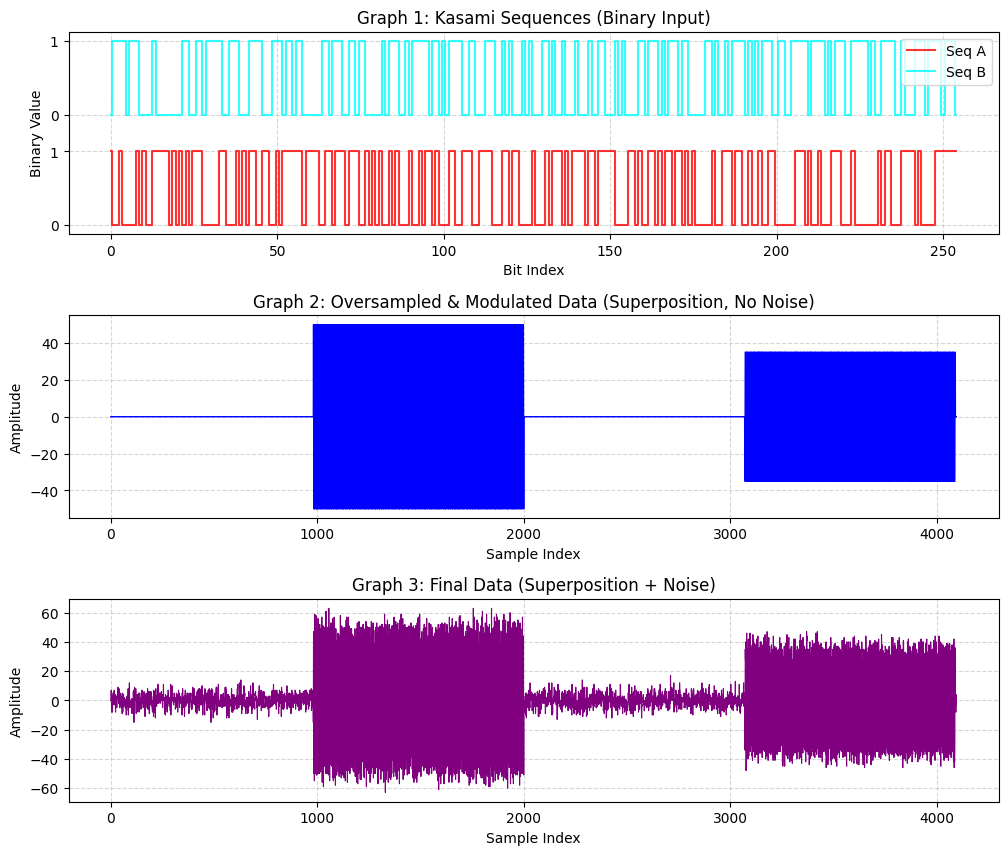

In [ ]:
import random
import sys
import math  # Added for sin() and radians()
import matplotlib.pyplot as plt # Added for graphing

# ==========================================
# 1. HARDCODED SEQUENCES
# ==========================================
KASAMI_SEQ_A = "100100001010011111010101011100000110001010110011001011111101111001101110111001010100101000100101101000110011100111100011011000010001011101011110110111110000110100110101101101010000010011101100100100110000001110100100011100010000000101100011110100001111111"
KASAMI_SEQ_B = "011110111000010000000011001101111100111000111100011101101100000011011100110110000010111001011111011010111100110001110010100010100011010010001000100110001010000110111010111011000001101001011110101011100110011111011110101110011111010011110010001110111101110"

# ==========================================
# 2. CONFIGURATION MODE
# ==========================================
USE_HARDCODED_INPUTS = True  # Set to False to test Phase Inputs

# Defaults if USE_HARDCODED_INPUTS is True
HC_TOTAL_SAMPLES = 4096
HC_END_INDEX_A   = 2000    
HC_END_INDEX_B   = 4088    
HC_PHASE_A       = 0      # Degrees
HC_PHASE_B       = 45     # Degrees (Test the strong signal case)
HC_SIGNAL_AMP    = 50     
HC_NOISE_AMP     = 5      

# ==========================================
# 3. CONSTANTS & COLORS
# ==========================================
OVERSAMPLE_FACTOR = 4
SEQ_LENGTH_BITS   = 255
SEQ_LENGTH_SAMPLES = SEQ_LENGTH_BITS * OVERSAMPLE_FACTOR  # 1020 samples

# ANSI Colors
C_RESET  = '\033[0m'
C_NOISE  = '\033[90m' # Gray
C_SEQ_A  = '\033[91m' # Red
C_SEQ_B  = '\033[96m' # Cyan
C_BOTH   = '\033[95m' # Purple (Overlap)
C_GREEN  = '\033[92m'
C_YELLOW = '\033[93m'

def get_valid_int(prompt, min_val, max_val, default=None):
    while True:
        try:
            p_str = f"{prompt} ({min_val}-{max_val})"
            if default is not None:
                p_str += f" [{default}]"
            
            user_input = input(f"{p_str}: ")
            
            if user_input.strip() == "" and default is not None:
                return default
            
            val = int(user_input)
            if min_val <= val <= max_val:
                return val
            print(f"Error: Value must be between {min_val} and {max_val}")
        except ValueError:
            print("Error: Invalid integer.")

def to_hex_8bit(val):
    """Converts int (-128 to 127) to 2-char Hex (2's complement)."""
    # Clip to verify validity before hex conversion
    if val > 127: val = 127
    if val < -128: val = -128
    if val < 0: val = (val + 256) & 0xFF
    return f"{val:02X}"

def inject_sequence_sine(buffer, mask_buf, seq_str, end_idx, amplitude, phase_deg, mask_bit):
    """
    Generates BPSK modulated sine waves with configurable phase shift.
    Phase Shift 0 deg -> Samples at 0, 90, 180, 270 (Ideal Sin: 0, 1, 0, -1)
    Phase Shift 45 deg -> Samples at 45, 135, 225, 315
    """
    if end_idx == 0: return
    
    start_idx = end_idx - SEQ_LENGTH_SAMPLES + 1
    
    # Pre-calculate radians for the phase shift
    phase_rad = math.radians(phase_deg)

    for i, bit in enumerate(seq_str):
        # BPSK Polarity: '1' -> +1, '0' -> -1 (180 deg phase flip)
        polarity = 1 if bit == '1' else -1
        
        for k in range(OVERSAMPLE_FACTOR):
            # Calculate sampling angle: (0, 90, 180, 270) + Phase Shift
            angle_deg = (k * 90)
            angle_rad = math.radians(angle_deg)
            
            # The Formula: Amp * Polarity * sin(theta + phi)
            raw_val = amplitude * polarity * math.sin(angle_rad + phase_rad)
            
            # Accumulate into buffer (integer)
            idx = start_idx + (i * OVERSAMPLE_FACTOR) + k
            if 0 <= idx < len(buffer):
                buffer[idx] += int(raw_val)
                mask_buf[idx] |= mask_bit

def main():
    print(f"\n{C_GREEN}=== FPGA Signal Generator (BPSK Sine Wave) ==={C_RESET}")
    print(f"Sequence Length: {SEQ_LENGTH_BITS} bits * {OVERSAMPLE_FACTOR}x = {SEQ_LENGTH_SAMPLES} samples")

    # --- INPUT PHASE ---
    if USE_HARDCODED_INPUTS:
        print(f"{C_YELLOW}[INFO] Using Hardcoded Inputs{C_RESET}")
        total_samples = HC_TOTAL_SAMPLES
        end_idx_a = HC_END_INDEX_A
        end_idx_b = HC_END_INDEX_B
        phase_a = HC_PHASE_A
        phase_b = HC_PHASE_B
        sig_amp = HC_SIGNAL_AMP
        noise_amp = HC_NOISE_AMP
    else:
        # 1. Total Samples
        total_samples = get_valid_int("Total Samples", SEQ_LENGTH_SAMPLES + 100, 65535, 4096)
        
        # 2. Sequence A
        print(f"\n{C_GREEN}--- Sequence A Setup ---{C_RESET}")
        min_end = SEQ_LENGTH_SAMPLES - 1
        max_end = total_samples - 1
        end_idx_a = get_valid_int("End Index A (0 to disable)", 0, max_end, 2000)
        phase_a = 0
        if end_idx_a != 0:
            phase_a = get_valid_int("Phase Misalignment A (degrees)", 0, 360, 0)
        
        # 3. Sequence B
        print(f"\n{C_GREEN}--- Sequence B Setup ---{C_RESET}")
        end_idx_b = get_valid_int("End Index B (0 to disable)", 0, max_end, 3000)
        phase_b = 0
        if end_idx_b != 0:
            phase_b = get_valid_int("Phase Misalignment B (degrees)", 0, 360, 45)

        # 4. Amplitudes
        print(f"\n{C_GREEN}--- Signal Properties ---{C_RESET}")
        sig_amp = get_valid_int("Signal Amplitude", 1, 127, 50)
        noise_amp = get_valid_int("Noise Amplitude", 0, 50, 5)

    # --- GENERATION PHASE ---
    samples = [0] * total_samples
    mask = [0] * total_samples 
    
    # Inject Signals with specified phases
    inject_sequence_sine(samples, mask, KASAMI_SEQ_A, end_idx_a, sig_amp, phase_a, 1)
    inject_sequence_sine(samples, mask, KASAMI_SEQ_B, end_idx_b, sig_amp, phase_b, 2)

    # Capture clean data for Graph 2 (Before Noise)
    clean_samples_for_plot = samples[:]

    # Add Noise & Hex Conversion
    final_hex_chars = []
    noisy_samples_for_plot = [] # Capture noisy data for Graph 3
    
    for s in samples:
        noise = int(random.gauss(0, noise_amp))
        val = s + noise
        noisy_samples_for_plot.append(val) 
        final_hex_chars.append(to_hex_8bit(val))

    # --- FILE OUTPUT ---
    full_hex_str = "".join(final_hex_chars)
    filename = "signal_output.txt"
    with open(filename, "w") as f:
        f.write(full_hex_str)

    # --- DETAILED REPORT ---
    print("\n" + "="*50)
    print(f"{C_GREEN}              GENERATION REPORT              {C_RESET}")
    print("="*50)
    print(f"Total Samples  : {total_samples}")
    print(f"Noise Amp      : +/- {noise_amp}")
    print("-" * 50)
    
    if end_idx_a > 0:
        print(f"Sequence A     : {C_SEQ_A}ACTIVE{C_RESET}")
        print(f"  > Phase Shift: {phase_a}°")
        print(f"  > End Index  : {end_idx_a}")
    else:
        print(f"Sequence A     : {C_NOISE}DISABLED{C_RESET}")

    if end_idx_b > 0:
        print(f"Sequence B     : {C_SEQ_B}ACTIVE{C_RESET}")
        print(f"  > Phase Shift: {phase_b}°")
        print(f"  > End Index  : {end_idx_b}")
    else:
        print(f"Sequence B     : {C_NOISE}DISABLED{C_RESET}")
    
    print("="*50)
    print(f"[SUCCESS] Data saved to '{filename}'")

    # --- VISUALIZATION (CONSOLE) ---
    print(f"\n{C_RESET}Visualization Legend:")
    print(f"{C_NOISE}■ Noise Only{C_RESET} | {C_SEQ_A}■ Seq A{C_RESET} | {C_SEQ_B}■ Seq B{C_RESET} | {C_BOTH}■ Overlap{C_RESET}")
    
    do_print = input("\nShow colored hex dump? (y/N): ").lower()
    if do_print == 'y':
        print("-" * 64)
        row_count = 0
        for i, hex_val in enumerate(final_hex_chars):
            m = mask[i]
            color = C_NOISE
            if m == 1: color = C_SEQ_A
            elif m == 2: color = C_SEQ_B
            elif m == 3: color = C_BOTH
            print(f"{color}{hex_val}{C_RESET}", end="")
            row_count += 1
            if row_count >= 32: 
                print() 
                row_count = 0
        print("\n" + "-" * 64)

    # --- MATPLOTLIB GRAPHS ---
    print("\nGenerating Graphs...")
    
    # Create subplots: 3 rows, 1 column
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
    plt.subplots_adjust(hspace=0.4)

    # 1. Kasami Sequence (Binary)
    # Converting string '1001' to int list [1,0,0,1]
    bits_a = [int(b) for b in KASAMI_SEQ_A]
    bits_b = [int(b) for b in KASAMI_SEQ_B]
    
    ax1.step(range(len(bits_a)), bits_a, where='mid', color='red', label='Seq A', alpha=0.8)
    # Offset Seq B by 1.5 just to make it visible on the same graph without overlap
    offset_bits_b = [b + 1.5 for b in bits_b]
    ax1.step(range(len(bits_b)), offset_bits_b, where='mid', color='cyan', label='Seq B', alpha=0.8)
    ax1.set_title('Graph 1: Kasami Sequences (Binary Input)')
    ax1.set_xlabel('Bit Index')
    ax1.set_ylabel('Binary Value')
    ax1.set_yticks([0, 1, 1.5, 2.5])
    ax1.set_yticklabels(['0', '1', '0', '1'])
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc="upper right")

    # 2. Data after oversampling and modulation (Discrete, Clean)
    ax2.plot(clean_samples_for_plot, color='blue', linewidth=1)
    ax2.set_title('Graph 2: Oversampled & Modulated Data (Superposition, No Noise)')
    ax2.set_xlabel('Sample Index')
    ax2.set_ylabel('Amplitude')
    ax2.grid(True, linestyle='--', alpha=0.5)

    # 3. Data after superposition with noise (Discrete, Final)
    ax3.plot(noisy_samples_for_plot, color='purple', linewidth=0.8)
    ax3.set_title('Graph 3: Final Data (Superposition + Noise)')
    ax3.set_xlabel('Sample Index')
    ax3.set_ylabel('Amplitude')
    ax3.grid(True, linestyle='--', alpha=0.5)

    print("Displaying plots...")
    plt.show()

if __name__ == "__main__":
    main()

In [111]:
import serial
import sys
import os

# ===========================
# CONFIG
# ===========================
DEFAULT_PORT = '/dev/ttyUSB0'   # change if needed
BAUD_RATE = 115200              # change if needed
INPUT_FILE = 'signal_output.txt'


def load_hex_file(path):
    if not os.path.exists(path):
        print(f"❌ File not found: {path}")
        sys.exit(1)

    with open(path, 'r') as f:
        data = f.read().strip()

    if not data:
        print("❌ File is empty")
        sys.exit(1)

    # ------
    # Flexible hex parsing
    # Supports:
    # AA BB CC
    # AA,BB,CC
    # AABBCC
    # ------
    tokens = []

    if any(c in data for c in [',', ' ', '\n', '\t']):
        # split by any whitespace or commas
        for t in data.replace(',', ' ').split():
            tokens.append(t)
    else:
        # continuous hex string: split every 2 chars
        if len(data) % 2 != 0:
            print("❌ Hex string length must be even")
            sys.exit(1)
        tokens = [data[i:i+2] for i in range(0, len(data), 2)]

    try:
        byte_values = bytes(int(t, 16) for t in tokens)
    except ValueError as e:
        print(f"❌ Invalid hex in file: {e}")
        sys.exit(1)

    return byte_values


def main():
    print("Reading data...")
    payload = load_hex_file('signal_output.txt')
    print(f"Loaded {len(payload)} bytes")

    # Ignore Jupyter kernel args like --f=/path
    args = [a for a in sys.argv[1:] if not a.startswith("--")]

    port = DEFAULT_PORT
    if len(args) > 0:
        port = args[0]


    print(f"Opening {port} @ {BAUD_RATE} baud...")
    try:
        ser = serial.Serial(port, BAUD_RATE, timeout=1)
    except Exception as e:
        print(f"❌ Failed to open serial port: {e}")
        sys.exit(1)

    input("Press ENTER to send data... ")

    try:
        written = ser.write(payload)
        ser.flush()
        print(f"✅ Sent {written} bytes")
    except Exception as e:
        print(f"❌ Failed to send: {e}")
    finally:
        ser.close()
        print("Serial port closed.")


if __name__ == "__main__":
    main()


Reading data...
Loaded 4096 bytes
Opening /dev/ttyUSB0 @ 115200 baud...
✅ Sent 4096 bytes
Serial port closed.


In [112]:
import serial
import sys
import time

def start_uart_logger():
    # --- Configuration ---
    default_filename = "uart_session_log.bin"
    
    print("--- Python UART Data Logger (Binary Mode) ---")
    
    # 1. User Input for Connection
    port_name = "/dev/ttyUSB0"  # Default port
    baud_rate = "115200"  # Default baud rate
    
    try:
        # Initialize Serial Connection
        ser = serial.Serial(port=port_name, baudrate=int(baud_rate), timeout=0.1)
        
        print(f"\nSuccessfully opened {port_name} at {baud_rate} baud.")
        print("Note: The script is currently listening to the line state.")
        
        # 2. Wait for User Input to Start
        input("\n>>> Press ENTER to begin recording data to file... <<<")
        print(f"Recording started! Pure binary data is being saved to '{default_filename}'.")
        print("Press Ctrl+C (KeyboardInterrupt) to stop the session.\n")

        # Open file in binary write mode ('wb')
        # This clears the file and prepares it for raw byte writing
        with open(default_filename, 'wb') as file:
            
            while True:
                # 3. Check if data is waiting in the buffer
                if ser.in_waiting > 0:
                    # Read the bytes available
                    data_bytes = ser.read(ser.in_waiting)
                    
                    # Write ONLY the raw bytes to the file
                    file.write(data_bytes)
                    file.flush() 
                    
                    # Optional: Print HEX representation to console for monitoring
                    # (This goes to screen only, NOT the file)
                    hex_output = " ".join([f"{b:02X}" for b in data_bytes]) + " "
                    sys.stdout.write(hex_output)
                    sys.stdout.flush()

    except serial.SerialException as e:
        print(f"\nError opening serial port: {e}")
    except KeyboardInterrupt:
        # 4. Stop on User Input (Ctrl+C)
        print("\n\n>>> Stop command received. Closing connection.")
        if 'ser' in locals() and ser.is_open:
            ser.close()
            
        print(f"Session finalized. Pure data saved to: {default_filename}")
    except ValueError:
        print("\nError: Please enter a valid integer for the baud rate.")

if __name__ == "__main__":
    start_uart_logger()

--- Python UART Data Logger (Binary Mode) ---

Successfully opened /dev/ttyUSB0 at 115200 baud.
Note: The script is currently listening to the line state.


Recording started! Pure binary data is being saved to 'uart_session_log.bin'.
Press Ctrl+C (KeyboardInterrupt) to stop the session.

D3 D7 F8 0F 6C F1 D3 CD 0F 5A 00 98 F2 0F 5C 0E B0 12 00 4F 00 54 0E 00 90 F2 33 0C 00 4A FC BB FA 0F 3E 06 98 EA 0F 20 03 C8 05 00 85 00 0C 1D 00 BB FF 57 F9 0F F6 FD 53 D6 0F 6C 00 A0 04 00 1D 03 DC 36 00 45 03 4C 11 00 49 03 D4 E8 0F F7 FC A7 EF 0F DC F6 EB F5 0F D8 FD 6B F3 0F AA 05 10 F5 0F 8D 01 BC 0D 00 40 FD D3 1E 00 15 00 AC FD 0F 91 02 24 E5 0F B7 00 94 FF 0F CC FD 13 17 00 E8 FE FB 11 00 17 01 5C 06 00 C1 00 44 EE 0F 98 00 A8 DD 0F 7C 02 D8 00 00 BA 03 C0 1E 00 BD FD C7 FF 0F 65 F7 D7 E3 0F 2A FD 13 FE 0F 1A 04 A8 16 00 B8 02 08 01 00 0C 00 F8 F0 0F F9 FE 87 03 00 BA FE EB 0D 00 AD 00 54 FE 0F 83 02 7C F4 0F 18 03 C8 FC 0F AE 03 38 01 00 FE FC 53 07 00 84 F6 2B 0C 00 4D 00 1C 03 00 80 09 08 00 00 2F 00 94 F9 0F FA F6 0B F2 0F 21 01 84 F9 0F FE 0B 98 FC 0F 55 FE 07 06 00 8A F0 8B 11 00 24 F9 1B FC 0F 6E 00 C8 EB 0F 4A 07 10 05 00 82 0F 88 17 00 

Auto-Detected Alignment Offset: 3
Total Samples Processed: 3750
Peak Score A: 25793 at Sample Index: 1662
Peak Score B: 8475 at Sample Index: 3749


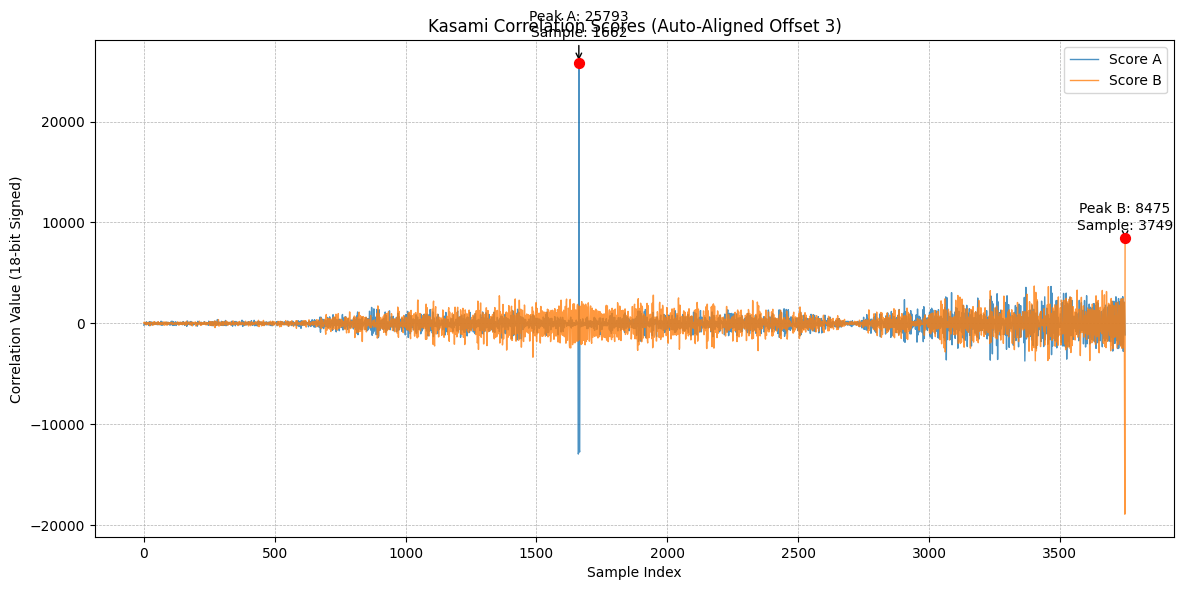

In [109]:
import struct
import matplotlib.pyplot as plt
import numpy as np

def sign_extend(value, bits):
    """Converts raw unsigned int to signed integer based on bit width."""
    sign_bit = 1 << (bits - 1)
    return (value & (sign_bit - 1)) - (value & sign_bit)

def decode_stream(data, offset):
    score_a_list = []
    score_b_list = []
    packet_size = 5
    
    # Calculate number of full packets available
    num_packets = (len(data) - offset) // packet_size
    
    for i in range(num_packets):
        start = offset + (i * packet_size)
        chunk = data[start : start + packet_size]
        b0, b1, b2, b3, b4 = chunk[0], chunk[1], chunk[2], chunk[3], chunk[4]
        
        # --- RECONSTRUCT SCORE B (18-bit) ---
        # Byte 0 (8b) | Byte 1 (8b) | Byte 2 Lower (2b)
        raw_b = b0 | (b1 << 8) | ((b2 & 0x03) << 16)
        val_b = sign_extend(raw_b, 18)
        
        # --- RECONSTRUCT SCORE A (18-bit) ---
        # Byte 2 Upper (6b) | Byte 3 (8b) | Byte 4 Lower (4b)
        raw_a = ((b2 & 0xFC) >> 2) | (b3 << 6) | ((b4 & 0x0F) << 14)
        val_a = sign_extend(raw_a, 18)
        
        score_a_list.append(val_a)
        score_b_list.append(val_b)
        
    return score_a_list, score_b_list

def find_best_offset(data):
    """Finds the byte offset that results in the lowest signal noise."""
    best_offset = 0
    lowest_noise = float('inf')
    
    # Try offsets 0, 1, 2, 3, 4
    for offset in range(5):
        # We only need to check one score (Score A) to find sync
        scores_a, _ = decode_stream(data, offset)
        if not scores_a: continue
        
        # Calculate Standard Deviation (Noise Level)
        # Correct alignment has a flat line (low std dev)
        noise = np.std(scores_a)
        
        if noise < lowest_noise:
            lowest_noise = noise
            best_offset = offset
            
    return best_offset

# --- MAIN EXECUTION ---
filename = 'uart_session_log.bin'

try:
    with open(filename, 'rb') as f:
        file_data = f.read()

    # 1. Auto-Sync
    offset = find_best_offset(file_data)
    print(f"Auto-Detected Alignment Offset: {offset}")

    # 2. Decode Full Data
    scores_a, scores_b = decode_stream(file_data, offset)

    # --- NEW: Find Peak Values and Indices ---
    if scores_a and scores_b:
        peak_a_val = max(scores_a)
        peak_a_idx = scores_a.index(peak_a_val)
        
        peak_b_val = max(scores_b)
        peak_b_idx = scores_b.index(peak_b_val)

        print(f"Total Samples Processed: {len(scores_a)}")
        print(f"Peak Score A: {peak_a_val} at Sample Index: {peak_a_idx}")
        print(f"Peak Score B: {peak_b_val} at Sample Index: {peak_b_idx}")
    else:
        print("No data decoded.")
        peak_a_idx = peak_b_idx = 0 # Default to avoid plot errors
        peak_a_val = peak_b_val = 0

    # 3. Plotting
    plt.figure(figsize=(12, 6))
    
    # Plot Score A (Blue)
    plt.plot(scores_a, label='Score A', color='#1f77b4', alpha=0.8, linewidth=1)
    
    # Plot Score B (Orange)
    plt.plot(scores_b, label='Score B', color='#ff7f0e', alpha=0.8, linewidth=1)

    # --- NEW: Highlight Peaks on Plot ---
    # Highlight Peak A
    plt.scatter(peak_a_idx, peak_a_val, color='red', s=50, zorder=5)
    plt.annotate(f'Peak A: {peak_a_val}\nSample: {peak_a_idx}', 
                 xy=(peak_a_idx, peak_a_val), 
                 xytext=(peak_a_idx, peak_a_val + (peak_a_val * 0.1)),
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 horizontalalignment='center')

    # Highlight Peak B
    plt.scatter(peak_b_idx, peak_b_val, color='red', s=50, zorder=5)
    plt.annotate(f'Peak B: {peak_b_val}\nSample: {peak_b_idx}', 
                 xy=(peak_b_idx, peak_b_val), 
                 xytext=(peak_b_idx, peak_b_val + (peak_b_val * 0.1)),
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 horizontalalignment='center')
    
    plt.title(f"Kasami Correlation Scores (Auto-Aligned Offset {offset})")
    plt.xlabel("Sample Index")
    plt.ylabel("Correlation Value (18-bit Signed)")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")